# **Import Library Progam**

In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Load Dataset Iris**

In [3]:
# Sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/gdrive')

# load dataset
import pandas as pd

df = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum05/datasets/Iris.csv', sep=',')
df.head()

Mounted at /content/gdrive


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# melihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# **Data Preprocessing**

In [4]:
# cek missing value
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [5]:
# cek duplikat
df.duplicated().sum()

np.int64(0)

# **Data Understanding (Exploratory Data Analysis)**


/tmp/ipython-input-1365077307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Species', data=df, palette='viridis')


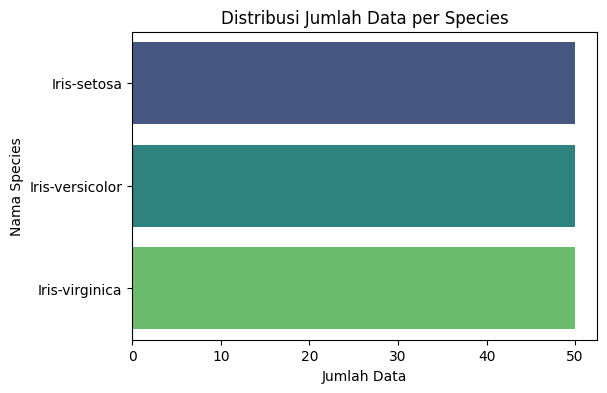

In [10]:
# visualisasi distribusi label target (spesies)
plt.figure(figsize=(6,4))
sns.countplot(y='Species', data=df, palette='viridis')
plt.title('Distribusi Jumlah Data per Species')
plt.xlabel('Jumlah Data')
plt.ylabel('Nama Species')
plt.show()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


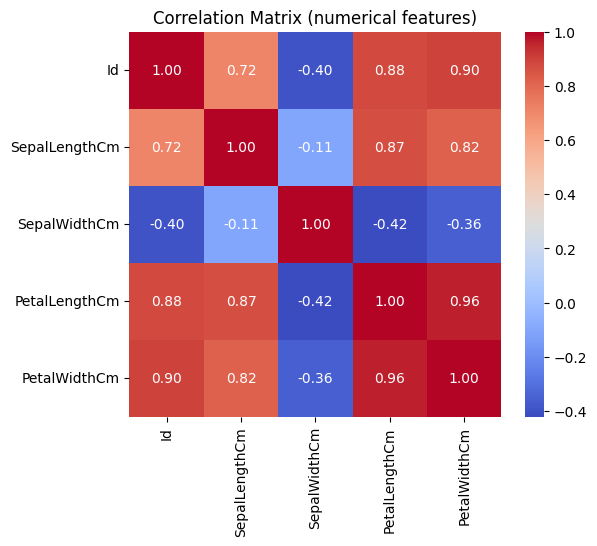

In [13]:
# matriks korelasi (numerik) dan ringkasan
# korelasi membantu melihat keterkaitan antar fitur
display(df.describe())

# visualisasi korelasi antar fitur numerik
plt.figure(figsize=(6,5))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (numerical features)')
plt.show()

# **Data Preparation**

In [16]:
# menentukan fitur (variabel input) dan target (label output)
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target = 'Species'

X = df[features].copy()   # fitur numerik
y = df[target].copy()     # target (label)

In [18]:
# mengubah label (string) menjadi angka agar bisa digunakan model sklearn
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Mapping label ke angka:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

Mapping label ke angka:
  Iris-setosa -> 0
  Iris-versicolor -> 1
  Iris-virginica -> 2


In [19]:
# membagi data menjadi data latih dan data uji agar model dapat dievaluasi secara objektif

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print("Ukuran data training:", X_train.shape)
print("Ukuran data testing :", X_test.shape)

Ukuran data training: (120, 4)
Ukuran data testing : (30, 4)


# **Modelling**

In [20]:
# membuat dan melatih model Decision Tree untuk klasifikasi data Iris
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

print("Model Decision Tree berhasil dilatih!")

Model Decision Tree berhasil dilatih!


/tmp/ipython-input-3274497811.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp, y=imp.index, palette="crest")


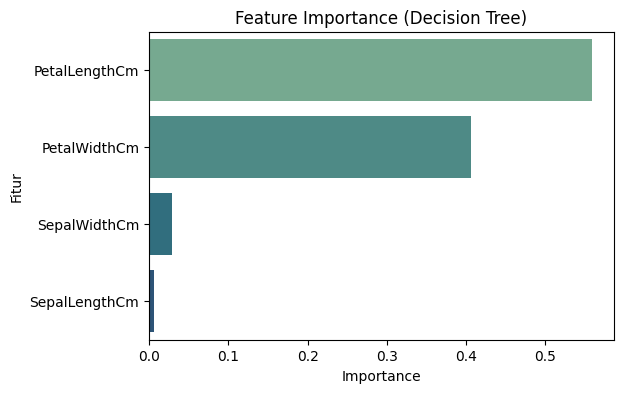

,0
PetalLengthCm,0.558568
PetalWidthCm,0.406015
SepalWidthCm,0.029167
SepalLengthCm,0.006250


In [41]:
# feature importance (fitur yg paling berpengaruh terhadap hasil klasifikasi)

# ambil nilai importance dari model Decision Tree
imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)

# visualisasi importance fitur
plt.figure(figsize=(6,4))
sns.barplot(x=imp, y=imp.index, palette="crest")
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.title("Feature Importance (Decision Tree)")
plt.show()

# tampilkan nilai numerik
imp

In [42]:
# hyperparameter tuning (max_depth terbaik)
scores = {}
for d in range(2, 9):  # Coba kedalaman pohon dari 2 sampai 8
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    scores[d] = accuracy_score(y_test, m.predict(X_test))

# tampilkan semua hasil
print("Akurasi untuk setiap max_depth:")
for depth, acc in scores.items():
    print(f"  depth={depth}: {acc*100:.2f}%")

# pilih yang terbaik
best_d = max(scores, key=scores.get)
print(f"✅ Best max_depth: {best_d} | Accuracy: {scores[best_d]*100:.2f}%")

Akurasi untuk setiap max_depth:
  depth=2: 93.33%
  depth=3: 96.67%
  depth=4: 93.33%
  depth=5: 93.33%
  depth=6: 93.33%
  depth=7: 93.33%
  depth=8: 93.33%
✅ Best max_depth: 3 | Accuracy: 96.67%


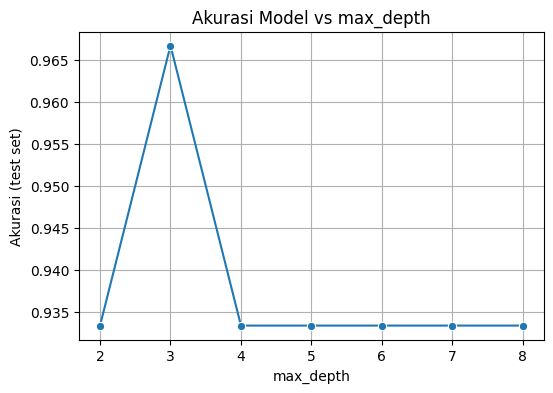

In [43]:
# visualisasi hasil tuning max_depth
plt.figure(figsize=(6,4))
sns.lineplot(x=list(scores.keys()), y=list(scores.values()), marker='o')
plt.title("Akurasi Model vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("Akurasi (test set)")
plt.grid(True)
plt.show()

# **Evaluation**

In [44]:
# mengukur performa model menggunakan metrik evaluasi umum
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Akurasi pada data testing: {acc*100:.2f}%\n")

Akurasi pada data testing: 93.33%



In [45]:
# confusion Matrix (numerik)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (raw):\n", cm)

Confusion Matrix (raw):
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


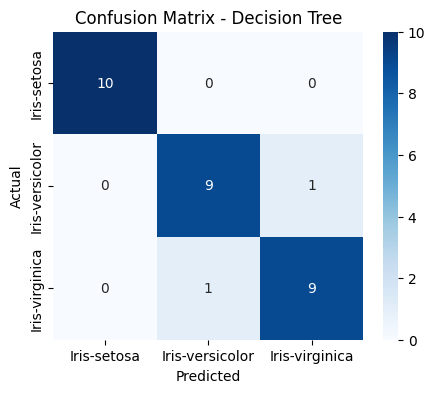

In [46]:
# visualisasi Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [47]:
# classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



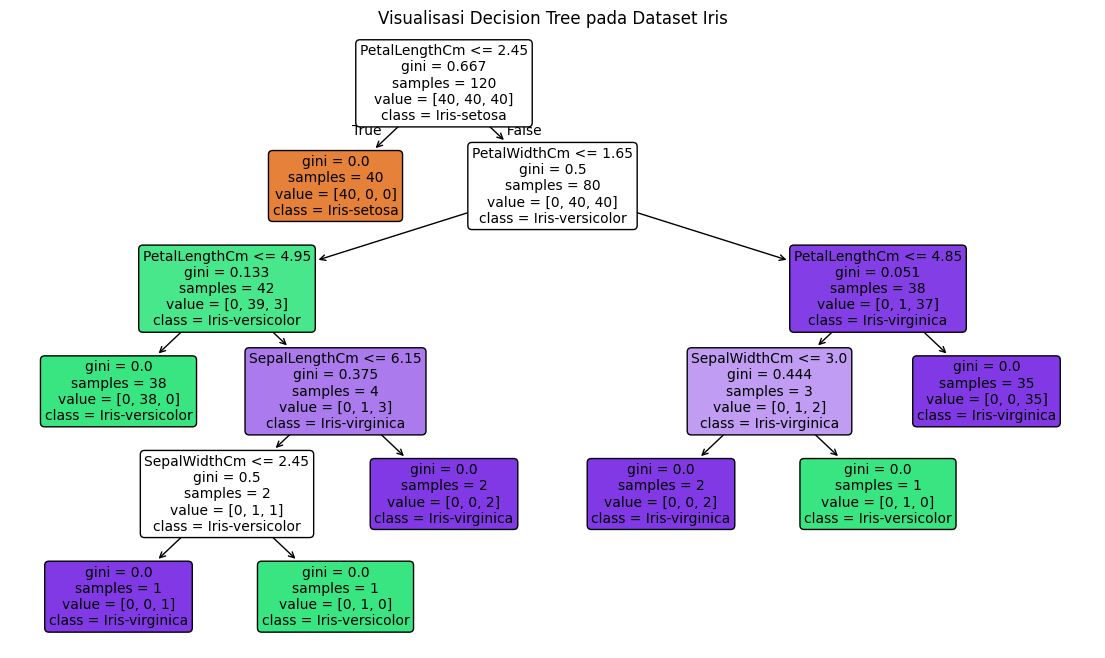

In [48]:
# visualisasi model decision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))
plot_tree(clf, feature_names=features, class_names=le.classes_, filled=True, rounded=True, fontsize=10)
plt.title('Visualisasi Decision Tree pada Dataset Iris')
plt.show()

# **Deployment**

In [49]:
# simpan model ke drive
import joblib
save_path = '/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum05/models/decision_tree_iris.pkl'

# simpan model, encoder, dan daftar fitur
joblib.dump({'model': clf, 'encoder': le, 'features': features}, save_path)

print(f"✅ Model berhasil disimpan ke: {save_path}")


✅ Model berhasil disimpan ke: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum05/models/decision_tree_iris.pkl


In [50]:
# menampilkan beberapa hasil prediksi agar mudah dicek manual
n = min(10, X_test.shape[0])
sample = X_test.iloc[:n].copy()
sample['Actual'] = le.inverse_transform(y_test[:n])
sample['Predicted'] = le.inverse_transform(clf.predict(X_test.iloc[:n]))

print("Contoh hasil prediksi:")
display(sample)

Contoh hasil prediksi:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Actual,Predicted
38,4.4,3.0,1.3,0.2,Iris-setosa,Iris-setosa
127,6.1,3.0,4.9,1.8,Iris-virginica,Iris-virginica
57,4.9,2.4,3.3,1.0,Iris-versicolor,Iris-versicolor
93,5.0,2.3,3.3,1.0,Iris-versicolor,Iris-versicolor
42,4.4,3.2,1.3,0.2,Iris-setosa,Iris-setosa
56,6.3,3.3,4.7,1.6,Iris-versicolor,Iris-versicolor
22,4.6,3.6,1.0,0.2,Iris-setosa,Iris-setosa
20,5.4,3.4,1.7,0.2,Iris-setosa,Iris-setosa
147,6.5,3.0,5.2,2.0,Iris-virginica,Iris-virginica
84,5.4,3.0,4.5,1.5,Iris-versicolor,Iris-versicolor
